In [ ]:
def normalizar_genes(df, col):
    # Convertimos a string, pasamos a mayúsculas y quitamos espacios
    df[col] = df[col].astype(str).str.upper().str.strip()
    # Eliminamos el sufijo 'HGNC:XXXXX' si existe
    df[col] = df[col].str.replace(r'HGNC:\d+', '', regex=True).str.strip()
    # Eliminamos los dos puntos ':' sobrantes si los hay
    df[col] = df[col].str.replace(':', '', regex=False).str.strip()
    return df

import pandas as pd

## Decipher

In [ ]:
file_decipher = "1gzwnqnzVpsOdEOJzFueJl04wAoGO5c0G"
url = f"https://drive.google.com/uc?id={file_decipher}"
decipher = pd.read_csv(url, sep='\t')
decipher.head()
print(decipher.columns)
decipher = decipher.rename(columns={'#gene': 'Gene'})
decipher = normalizar_genes(decipher, "Gene")

decipher_cols = {
    "pHaplo": "Decipher_HI_score",
    "pTriplo": "Decipher_TS_score"
}
decipher = decipher.rename(columns=decipher_cols)
decipher

Index(['#gene', 'pHaplo', 'pTriplo'], dtype='object')


,Gene,Decipher_HI_score,Decipher_TS_score
0,CACNA1C,0.998982,1.000000
1,ZNF462,1.000000,0.987996
2,CHD8,0.991650,1.000000
3,GRIN2B,0.996809,1.000000
4,ARID1A,0.998061,1.000000
...,...,...,...
18636,OR11H4,0.000315,0.008187
18637,OR5T2,0.004602,0.000000
18638,OR5D16,0.004228,0.002967
18639,OR5J2,0.003862,0.002804


## Clingen

In [ ]:
import pandas as pd
import gdown
file_clingen = "1YCMKuZTXA13ywkReLmpa-8jQYDVDVSEt"
gdown.download(f"https://drive.google.com/uc?id={file_clingen}", "file.csv", quiet=False)
# https://drive.google.com/file/d/1YCMKuZTXA13ywkReLmpa-8jQYDVDVSEt/view?usp=sharing
clingen = pd.read_csv("file.csv")

print(clingen.columns)
clingen = clingen.rename(columns={'Gene Symbol /Region Name': 'Gene'})
clingen = normalizar_genes(clingen, "Gene")

clingen_cols = {
    "HI Score": "Clingen_HI_score",
    "TS Score": "Clingen_TS_score",
    "%HI": "Clingen_%HI_score",
    "pLI": "Clingen_pLI_score",
    "LOEUF": "Clingen_LOEUF_score"
}
clingen = clingen.rename(columns=clingen_cols)
clingen = clingen[["Gene","Clingen_HI_score","Clingen_TS_score","Clingen_%HI_score","Clingen_pLI_score","Clingen_LOEUF_score"]]
clingen = clingen[clingen["Clingen_HI_score"] == "SufficientEvidence"]

# Convertimos a numérico, los errores (como los guiones especiales) se volverán NaN
clingen['Clingen_%HI_score'] = pd.to_numeric(clingen['Clingen_%HI_score'].astype(str).str.replace(',', '.'), errors='coerce')
clingen = clingen.dropna(subset=['Clingen_%HI_score'])

clingen

Downloading...
From: https://drive.google.com/uc?id=1YCMKuZTXA13ywkReLmpa-8jQYDVDVSEt
To: /content/file.csv
100%|██████████| 250k/250k [00:00<00:00, 76.2MB/s]

Index(['Type', 'Gene Symbol /Region Name', 'GRCh37', 'HI Score', 'TS Score',
       'OMIMMorbid', '%HI', 'pLI', 'LOEUF', 'LastEvaluated Date'],
      dtype='object')


,Gene,Clingen_HI_score,Clingen_TS_score,Clingen_%HI_score,Clingen_pLI_score,Clingen_LOEUF_score
482,AAGAB,SufficientEvidence,NoEvidence,50.94,0,1.16
488,ABCB4,SufficientEvidence,NoEvidence,32.55,0,0.62
490,ABCD1,SufficientEvidence,NoEvidence,59.98,1,0.15
509,ACVRL1,SufficientEvidence,NoEvidence,49.42,0.51,0.57
519,ADNP,SufficientEvidence,NoEvidence,9.79,1,0.11
...,...,...,...,...,...,...
2175,ZFHX4,SufficientEvidence,NoEvidence,2.42,1,0.25
2179,ZIC2,SufficientEvidence,NoEvidence,6.30,0.96,0.52
2180,ZIC3,SufficientEvidence,NoEvidence,4.79,0.92,0.36
2184,ZMYND11,SufficientEvidence,NoEvidence,16.99,1,0.17


In [ ]:
clingen

,Gene,Clingen_HI_score,Clingen_TS_score,Clingen_%HI_score,Clingen_pLI_score,Clingen_LOEUF_score
482,AAGAB,SufficientEvidence,NoEvidence,50.94,0,1.16
488,ABCB4,SufficientEvidence,NoEvidence,32.55,0,0.62
490,ABCD1,SufficientEvidence,NoEvidence,59.98,1,0.15
509,ACVRL1,SufficientEvidence,NoEvidence,49.42,0.51,0.57
519,ADNP,SufficientEvidence,NoEvidence,9.79,1,0.11
...,...,...,...,...,...,...
2175,ZFHX4,SufficientEvidence,NoEvidence,2.42,1,0.25
2179,ZIC2,SufficientEvidence,NoEvidence,6.30,0.96,0.52
2180,ZIC3,SufficientEvidence,NoEvidence,4.79,0.92,0.36
2184,ZMYND11,SufficientEvidence,NoEvidence,16.99,1,0.17


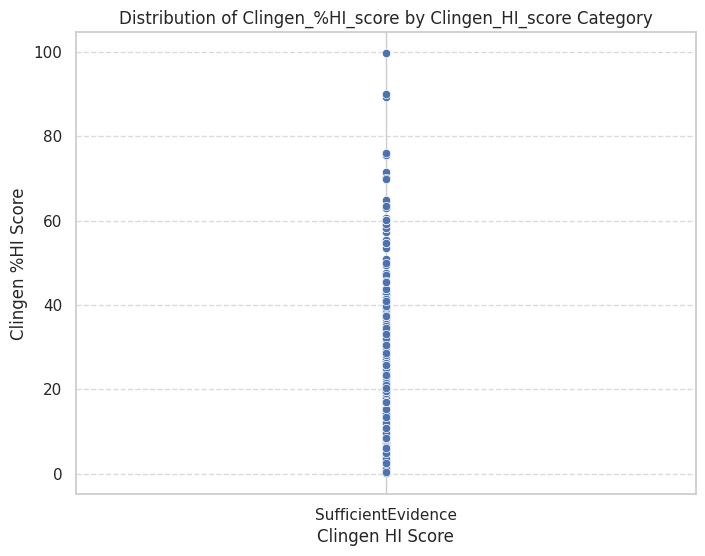

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Clingen_HI_score', y='Clingen_%HI_score', data=clingen)
plt.title('Distribution of Clingen_%HI_score by Clingen_HI_score Category')
plt.xlabel('Clingen HI Score')
plt.ylabel('Clingen %HI Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## GnomAD

In [ ]:
file_gnomad = "1NmsYyvH18hvNro1nS_PaKYBifUbueMl_"
gdown.download(f"https://drive.google.com/uc?id={file_gnomad}", "gnomad.v4.1.1.constraint_metrics.tsv.bgz", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1NmsYyvH18hvNro1nS_PaKYBifUbueMl_
From (redirected): https://drive.google.com/uc?id=1NmsYyvH18hvNro1nS_PaKYBifUbueMl_&confirm=t&uuid=2636b84c-44fe-4ba4-87d2-3766a8807946
To: /content/gnomad.v4.1.1.constraint_metrics.tsv.bgz
100%|██████████| 575M/575M [00:12<00:00, 45.4MB/s]


'gnomad.v4.1.1.constraint_metrics.tsv.bgz'

In [ ]:
gnomad = pd.read_csv(
    "gnomad.v4.1.1.constraint_metrics.tsv.bgz",
    sep="\t",
    compression="gzip"
)
print(gnomad.columns)
gnomad = normalizar_genes(gnomad, "gene")

cols_keep = ["gene","lof.oe","lof.oe_ci.lower","lof.oe_ci.upper","lof.z_score","mis.z_score","syn.z_score","constraint_flags"]
gnomad = gnomad[cols_keep]
gnomad = gnomad.rename(columns={"gene": "Gene","lof.oe": "LOF_OE","lof.oe_ci.lower": "LOF_OE_lower",
    "lof.oe_ci.upper": "LOEUF","lof.z_score": "LOF_Z","mis.z_score": "MIS_Z","syn.z_score": "SYN_Z"})

gnomad

/tmp/ipykernel_3211/2508088549.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gnomad = pd.read_csv(


Index(['gene', 'gene_id', 'transcript', 'canonical', 'mane_select',
       'transcript_version', 'transcript_type', 'transcript_level',
       'chromosome', 'start_position',
       ...
       'lof.gen_anc_obs.sas', 'lof.gen_anc_exp.global', 'lof.gen_anc_exp.afr',
       'lof.gen_anc_exp.amr', 'lof.gen_anc_exp.eas', 'lof.gen_anc_exp.nfe',
       'lof.gen_anc_exp.sas', 'lof.pLI', 'lof.pNull', 'lof.pRec'],
      dtype='object', length=113)


,Gene,LOF_OE,LOF_OE_lower,LOEUF,LOF_Z,MIS_Z,SYN_Z,constraint_flags
0,A1BG,0.95603,0.75098,1.22920,0.25307,-0.295160,-0.043795,[]
1,A1BG,0.95603,0.75098,1.22920,0.25307,-0.295160,-0.043795,[]
2,A1BG,0.77585,0.55025,1.11720,0.98928,0.307790,0.635880,[]
3,A1CF,0.69706,0.55302,0.88662,2.13260,1.047900,-0.428010,[]
4,A1CF,0.72289,0.57612,0.91499,1.95510,0.993390,-0.286350,[]
...,...,...,...,...,...,...,...,...
221893,NAN,2.71480,1.10990,8.54580,-1.24860,-3.008200,-2.159100,[]
221894,NAN,NaN,NaN,NaN,NaN,-0.005394,-0.012795,"[""no_exp_lof""]"
221895,NAN,NaN,NaN,NaN,NaN,-0.417530,0.215170,"[""no_exp_lof""]"
221896,NAN,NaN,NaN,NaN,NaN,2.460900,0.402140,"[""no_exp_lof""]"


In [ ]:
# Hacemos un merge outer (unión completa) activando el indicator
df_check = df_annot.merge(clingen, on="Gene", how="outer", indicator=True)

# Los genes que estaban en clingen pero NO en df_annot tendrán el valor 'right_only'
genes_afuera_clingen = df_check[df_check["_merge"] == "right_only"]["Gene"].unique()

print(f"Cantidad de genes de ClinGen que quedaron fuera: {len(genes_afuera_clingen)}")
print(genes_afuera_clingen)

Cantidad de genes de ClinGen que quedaron fuera: 0
[]


In [ ]:
df_annot = gnomad.copy()

# ClinGen
df_annot = df_annot.merge(clingen, on="Gene", how="left")

# DECIPHER
df_annot = df_annot.merge(decipher, on="Gene", how="left")

In [ ]:
df_annot = df_annot.sort_values("LOEUF")  # menor LOEUF = más constraint
df_annot = df_annot.drop_duplicates(subset="Gene", keep="first")
print(df_annot.columns)
df_annot

df = df_annot.drop_duplicates(subset="Gene", keep="first")
print(df.columns)
df


Index(['Gene', 'LOF_OE', 'LOF_OE_lower', 'LOEUF', 'LOF_Z', 'MIS_Z', 'SYN_Z',
       'constraint_flags', 'Clingen_HI_score', 'Clingen_TS_score',
       'Clingen_%HI_score', 'Clingen_pLI_score', 'Clingen_LOEUF_score',
       'Decipher_HI_score', 'Decipher_TS_score'],
      dtype='object')
Index(['Gene', 'LOF_OE', 'LOF_OE_lower', 'LOEUF', 'LOF_Z', 'MIS_Z', 'SYN_Z',
       'constraint_flags', 'Clingen_HI_score', 'Clingen_TS_score',
       'Clingen_%HI_score', 'Clingen_pLI_score', 'Clingen_LOEUF_score',
       'Decipher_HI_score', 'Decipher_TS_score'],
      dtype='object')


,Gene,LOF_OE,LOF_OE_lower,LOEUF,LOF_Z,MIS_Z,SYN_Z,constraint_flags,Clingen_HI_score,Clingen_TS_score,Clingen_%HI_score,Clingen_pLI_score,Clingen_LOEUF_score,Decipher_HI_score,Decipher_TS_score
185989,TAF1,0.008100,0.002879,0.038427,9.3493,8.50540,1.61320,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN
96651,KMT2A,0.008179,0.002906,0.038799,9.3036,5.01720,1.95620,[],SufficientEvidence,NoEvidence,17.01,1,0.07,0.999548,0.984725
177632,SON,0.009041,0.003213,0.042891,8.8410,3.42770,-1.02700,[],SufficientEvidence,NoEvidence,3.75,1,0.05,0.995382,0.881646
58535,EIF4G1,0.021268,0.010475,0.048670,11.3870,4.05770,-1.36800,[],NaN,NaN,NaN,NaN,NaN,0.972731,0.984396
175663,SMG1,0.010379,0.003688,0.049238,8.2404,4.50460,2.19460,[],NaN,NaN,NaN,NaN,NaN,0.992171,0.838870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220094,ZNF837,NaN,NaN,NaN,NaN,-2.30980,-3.42830,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.295266,0.214896
220220,ZNF860,NaN,NaN,NaN,NaN,1.82980,1.62210,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.617327,0.259940
220307,ZNF883,NaN,NaN,NaN,NaN,-0.34517,-0.29708,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
220423,ZNRF4,NaN,NaN,NaN,NaN,0.69749,-0.17813,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.221908,0.114304


## Modelo



Ver que predictor es mejor con respecto a la verdad de Clingen

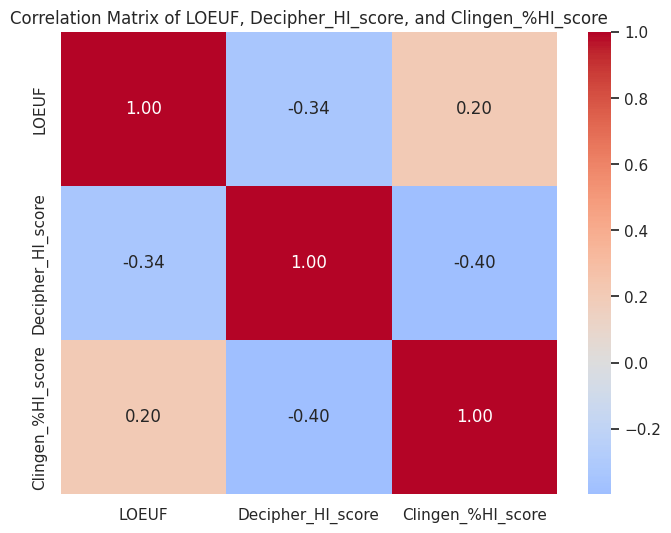

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the columns for correlation
cols_correlation = [
    "LOEUF",
    "Decipher_HI_score",
    "Clingen_%HI_score"
]

# Calculate the correlation matrix
correlation_matrix = df_annot[cols_correlation].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix of LOEUF, Decipher_HI_score, and Clingen_%HI_score")
plt.show()

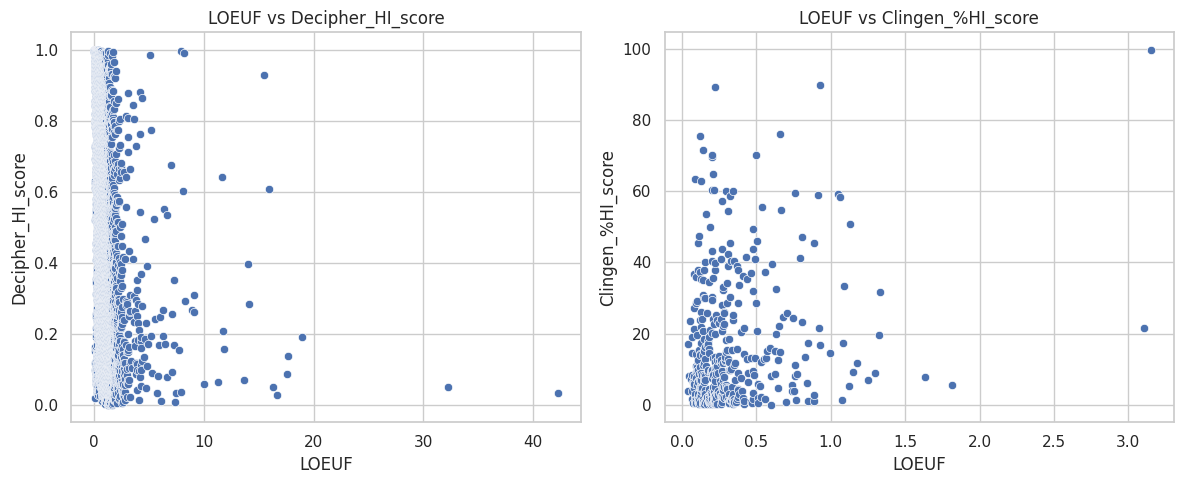

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Subplot 1: LOEUF vs Decipher_HI_score
plt.subplot(1, 2, 1)
sns.scatterplot(x="LOEUF", y="Decipher_HI_score", data=df_annot)
plt.title("LOEUF vs Decipher_HI_score")
plt.xlabel("LOEUF")
plt.ylabel("Decipher_HI_score")
plt.grid(True)

# Subplot 2: LOEUF vs Clingen_%HI_score
plt.subplot(1, 2, 2)
sns.scatterplot(x="LOEUF", y="Clingen_%HI_score", data=df_annot)
plt.title("LOEUF vs Clingen_%HI_score")
plt.xlabel("LOEUF")
plt.ylabel("Clingen_%HI_score")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Asumiendo que tu DataFrame principal se llama 'df'

# 1. Aislar el "Ground Truth" (Solo genes que ClinGen ya evaluó)
# Eliminamos las filas donde ClinGen no tiene datos para poder hacer la comparación justa
df_eval = df.dropna(subset=['Clingen_%HI_score']).copy()

# 2. Definir la Verdad Absoluta (Variable Y)
# Ajusta el "3" si en tu base de datos la haploinsuficiencia confirmada se marca distinto.
df_eval['y_true'] = df_eval['Clingen_%HI_score'].apply(lambda x: 1 if x >= 3 else 0)

# 3. Definir las Predicciones de las métricas que compiten
# LOEUF: gnomAD recomienda < 0.45 para predecir genes haploinsuficientes severos
df_eval['pred_LOEUF'] = df_eval['LOEUF'].apply(lambda x: 1 if pd.notnull(x) and x < 0.45 else 0)

# Decipher: Ajusta 'umbral_decipher' según la escala de tu métrica (ej. 0.90 para 90%)
umbral_decipher = 0.90
df_eval['pred_Decipher'] = df_eval['Decipher_HI_score'].apply(lambda x: 1 if pd.notnull(x) and x >= umbral_decipher else 0)

# 4. Función para calcular y mostrar las métricas
def evaluar_predictor(y_true, y_pred, nombre):
    # Calcular métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0) # Valor Predictivo Positivo
    recall = recall_score(y_true, y_pred, zero_division=0)       # Sensibilidad

    # Calcular Especificidad a través de la matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Imprimir reporte
    print(f"--- Resultados para {nombre} ---")
    print(f"Exactitud (Accuracy):  {acc:.2f} (Porcentaje de aciertos totales)")
    print(f"Precisión (PPV):       {precision:.2f} (Si dice que es HI, ¿qué tan seguro es?)")
    print(f"Sensibilidad (Recall): {recall:.2f} (De todos los HI reales, ¿cuántos encontró?)")
    print(f"Especificidad:         {specificity:.2f} (De los NO HI, ¿cuántos descartó correctamente?)\n")

# 5. Ejecutar la evaluación
evaluar_predictor(df_eval['y_true'], df_eval['pred_LOEUF'], 'gnomAD LOEUF (< 0.45)')
evaluar_predictor(df_eval['y_true'], df_eval['pred_Decipher'], f'Decipher (>= {umbral_decipher})')



--- Resultados para gnomAD LOEUF (< 0.45) ---
Exactitud (Accuracy):  0.59 (Porcentaje de aciertos totales)
Precisión (PPV):       0.71 (Si dice que es HI, ¿qué tan seguro es?)
Sensibilidad (Recall): 0.75 (De todos los HI reales, ¿cuántos encontró?)
Especificidad:         0.13 (De los NO HI, ¿cuántos descartó correctamente?)

--- Resultados para Decipher (>= 0.9) ---
Exactitud (Accuracy):  0.39 (Porcentaje de aciertos totales)
Precisión (PPV):       0.63 (Si dice que es HI, ¿qué tan seguro es?)
Sensibilidad (Recall): 0.45 (De todos los HI reales, ¿cuántos encontró?)
Especificidad:         0.23 (De los NO HI, ¿cuántos descartó correctamente?)



Gana Louef con respecto a decipher


🥇 'Nivel 1: Confirmado por ClinGen'

🥈'Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)'

🥉 'Nivel 3A: Alta Probabilidad (Solo gnomAD)'

🥉 'Nivel 3B: Sospecha Moderada (Solo DECIPHER)'

⚪ 'Nivel 4: Sin evidencia fuerte de HI'

## Hipotesis de haploinsuficiencia

In [ ]:
import pandas as pd
import numpy as np

# Asumiendo que tu DataFrame original se llama 'df'

def asignar_jerarquia_hi(row):
    # 🥇 Nivel 1: Verdad Absoluta Clínica (ClinGen)
    if pd.notnull(row['Clingen_%HI_score']):
        return 'Nivel 1: Confirmado por ClinGen'

    # 🥈 Niveles 2: Alta Probabilidad Estadística (gnomAD LOEUF < 0.45)
    elif pd.notnull(row['LOEUF']) and row['LOEUF'] < 0.45:
        # Subdivisión 2A: Coincide con una alta sospecha clínica en DECIPHER
        if pd.notnull(row['Decipher_HI_score']) and row['Decipher_HI_score'] >= 0.90:
            return 'Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)'
        # Subdivisión 2B: Fuerte restricción poblacional, pero aún sin evidencia en DECIPHER
        else:
            return 'Nivel 3A: Alta Probabilidad (Solo gnomAD)'

    # 🥉 Nivel 3: Sospecha Moderada Clínico-Fenotípica (DECIPHER)
    # Cae aquí si no es nivel 1, y su LOEUF es mayor a 0.45 (o nulo), pero DECIPHER tiene alta sospecha.
    elif pd.notnull(row['Decipher_HI_score']) and row['Decipher_HI_score'] >= 0.90:
        return 'Nivel 3B: Sospecha Moderada (Solo DECIPHER)'

    # ⚪ Nivel 4: Tolerante / Sin Evidencia Fuerte
    else:
        return 'Nivel 4: Sin evidencia fuerte de HI'

# Aplicar la función a cada fila para crear la nueva columna 'Score_HI_Integrado'
df['Score_HI_Integrado'] = df.apply(asignar_jerarquia_hi, axis=1)

# Ver un conteo rápido de cuántos genes cayeron en cada categoría
print("Distribución de Genes por Nivel de Evidencia de Haploinsuficiencia:")
print(df['Score_HI_Integrado'].value_counts())

df

Distribución de Genes por Nivel de Evidencia de Haploinsuficiencia:
Score_HI_Integrado
Nivel 4: Sin evidencia fuerte de HI               15613
Nivel 3A: Alta Probabilidad (Solo gnomAD)          1527
Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)     1331
Nivel 3B: Sospecha Moderada (Solo DECIPHER)         750
Nivel 1: Confirmado por ClinGen                     417
Name: count, dtype: int64


,Gene,LOF_OE,LOF_OE_lower,LOEUF,LOF_Z,MIS_Z,SYN_Z,constraint_flags,Clingen_HI_score,Clingen_TS_score,Clingen_%HI_score,Clingen_pLI_score,Clingen_LOEUF_score,Decipher_HI_score,Decipher_TS_score,Score_HI_Integrado
185989,TAF1,0.008100,0.002879,0.038427,9.3493,8.50540,1.61320,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nivel 3A: Alta Probabilidad (Solo gnomAD)
96651,KMT2A,0.008179,0.002906,0.038799,9.3036,5.01720,1.95620,[],SufficientEvidence,NoEvidence,17.01,1,0.07,0.999548,0.984725,Nivel 1: Confirmado por ClinGen
177632,SON,0.009041,0.003213,0.042891,8.8410,3.42770,-1.02700,[],SufficientEvidence,NoEvidence,3.75,1,0.05,0.995382,0.881646,Nivel 1: Confirmado por ClinGen
58535,EIF4G1,0.021268,0.010475,0.048670,11.3870,4.05770,-1.36800,[],NaN,NaN,NaN,NaN,NaN,0.972731,0.984396,Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)
175663,SMG1,0.010379,0.003688,0.049238,8.2404,4.50460,2.19460,[],NaN,NaN,NaN,NaN,NaN,0.992171,0.838870,Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220094,ZNF837,NaN,NaN,NaN,NaN,-2.30980,-3.42830,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.295266,0.214896,Nivel 4: Sin evidencia fuerte de HI
220220,ZNF860,NaN,NaN,NaN,NaN,1.82980,1.62210,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.617327,0.259940,Nivel 4: Sin evidencia fuerte de HI
220307,ZNF883,NaN,NaN,NaN,NaN,-0.34517,-0.29708,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nivel 4: Sin evidencia fuerte de HI
220423,ZNRF4,NaN,NaN,NaN,NaN,0.69749,-0.17813,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.221908,0.114304,Nivel 4: Sin evidencia fuerte de HI


In [ ]:
df.Score_HI_Integrado.value_counts()

,count
Score_HI_Integrado,
Nivel 4: Sin evidencia fuerte de HI,15613
Nivel 3A: Alta Probabilidad (Solo gnomAD),1527
Nivel 2: Alta Probabilidad (gnomAD + DECIPHER),1331
Nivel 3B: Sospecha Moderada (Solo DECIPHER),750
Nivel 1: Confirmado por ClinGen,417


### Graficos y distribucion

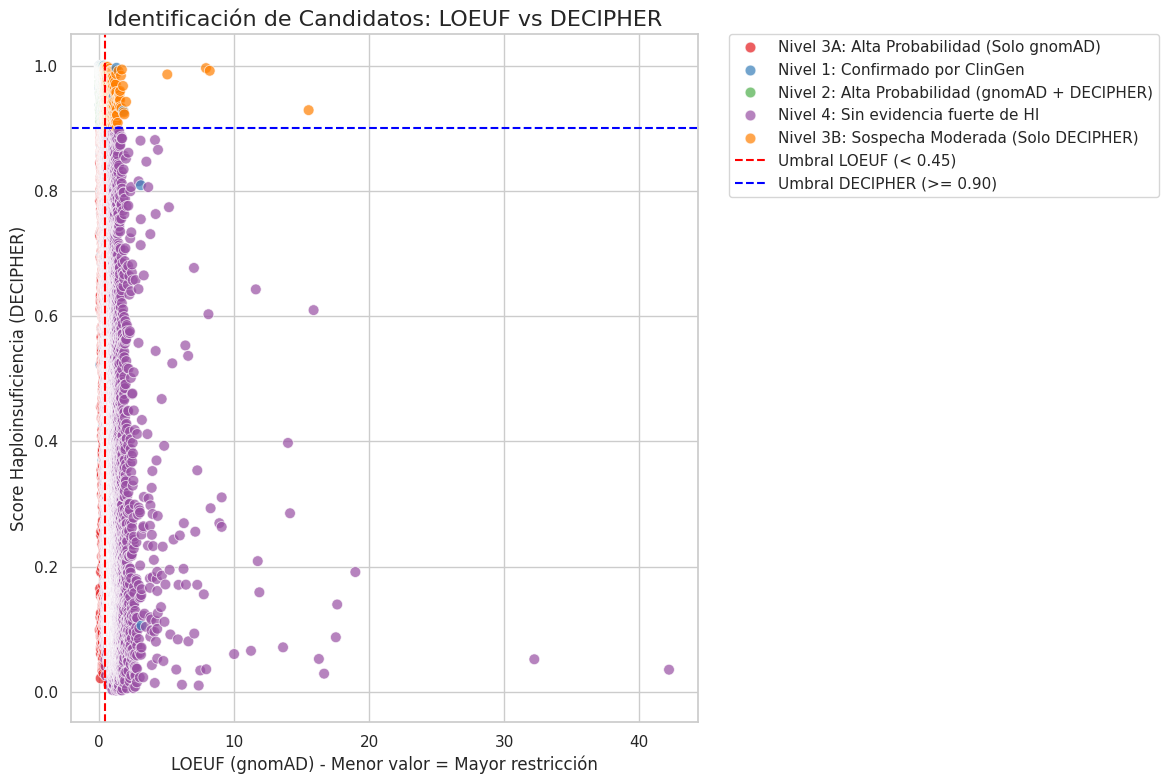

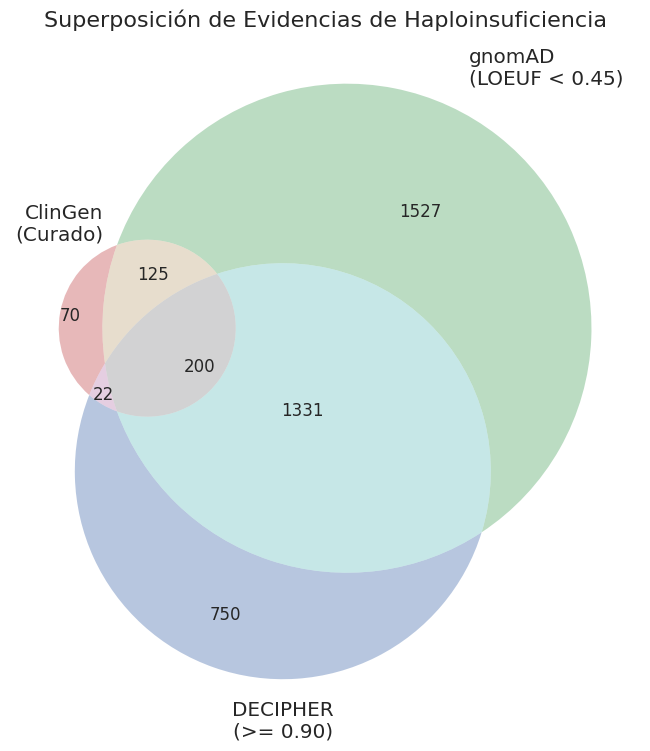

/tmp/ipykernel_3211/2519605547.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


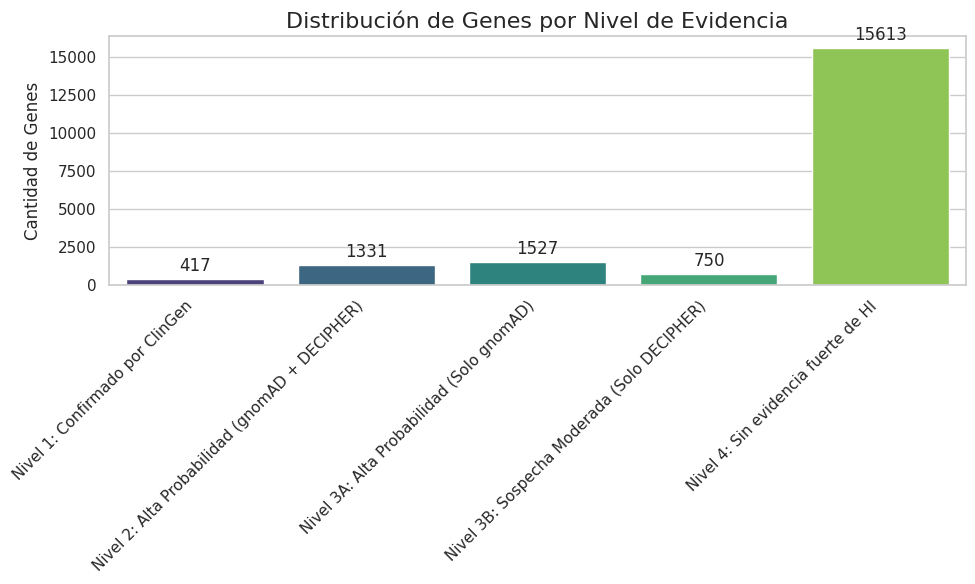

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

# Configurar el estilo visual general
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 1: Gráfico de Dispersión (Scatter Plot)
# Muestra dónde caen tus genes según los umbrales de LOEUF y DECIPHER
# ==========================================
plt.figure(figsize=(12, 8))

# Graficamos LOEUF en X y Decipher en Y.
# Usamos el Score_HI_Integrado para darle color a cada punto.
sns.scatterplot(
    data=df,
    x='LOEUF',
    y='Decipher_HI_score',
    hue='Score_HI_Integrado',
    palette='Set1',
    alpha=0.7,
    s=60
)

# Líneas de corte para los umbrales
# gnomAD recomienda < 0.45 para el 15% de genes más restringidos a pérdida de función
plt.axvline(x=0.45, color='red', linestyle='--', label='Umbral LOEUF (< 0.45)')
plt.axhline(y=0.90, color='blue', linestyle='--', label='Umbral DECIPHER (>= 0.90)')

plt.title('Identificación de Candidatos: LOEUF vs DECIPHER', fontsize=16)
plt.xlabel('LOEUF (gnomAD) - Menor valor = Mayor restricción', fontsize=12)
plt.ylabel('Score Haploinsuficiencia (DECIPHER)', fontsize=12)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 2: Diagrama de Venn
# Muestra la intersección de las evidencias para ver tu Nivel 2A
# ==========================================
plt.figure(figsize=(9, 9))

# Creamos conjuntos (sets) con los índices (nombres de los genes) que cumplen cada condición
set_clingen = set(df[df["Clingen_HI_score"] == "SufficientEvidence"].index)
set_gnomad = set(df[df['LOEUF'] < 0.45].index)
set_decipher = set(df[df['Decipher_HI_score'] >= 0.90].index)

# Dibujamos el diagrama de Venn
venn_diagram = venn3(
    [set_clingen, set_gnomad, set_decipher],
    ('ClinGen\n(Curado)', 'gnomAD\n(LOEUF < 0.45)', 'DECIPHER\n(>= 0.90)')
)

plt.title('Superposición de Evidencias de Haploinsuficiencia', fontsize=16)
plt.show()

# ==========================================
# GRÁFICO 3: Gráfico de Barras (Distribución Final)
# Muestra cuántos genes cayeron en cada categoría
# ==========================================
plt.figure(figsize=(10, 6))

# Definimos el orden en el que queremos que aparezcan las barras
orden_niveles = [
    'Nivel 1: Confirmado por ClinGen',
    'Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)',
    'Nivel 3A: Alta Probabilidad (Solo gnomAD)',
    'Nivel 3B: Sospecha Moderada (Solo DECIPHER)',
    'Nivel 4: Sin evidencia fuerte de HI'
]

# Creamos el gráfico de barras
ax = sns.countplot(
    data=df,
    x='Score_HI_Integrado',
    order=orden_niveles,
    palette='viridis'
)

# Añadimos los números exactos encima de cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Distribución de Genes por Nivel de Evidencia', fontsize=16)
plt.ylabel('Cantidad de Genes', fontsize=12)
plt.xlabel('', fontsize=12)
plt.tight_layout()
plt.show()

## Clinvar mix

In [ ]:
file_clingen = "1KhwHxEeAL1xT-fvPifwbAJzL2cxx1pVo"
gdown.download(f"https://drive.google.com/uc?id={file_clingen}", "clinvarmix.csv", quiet=False)

clinvarmix = pd.read_csv("clinvarmix.csv")
print(clinvarmix)

Downloading...
From (original): https://drive.google.com/uc?id=1KhwHxEeAL1xT-fvPifwbAJzL2cxx1pVo
From (redirected): https://drive.google.com/uc?id=1KhwHxEeAL1xT-fvPifwbAJzL2cxx1pVo&confirm=t&uuid=7b60fae5-9ff9-4d9d-85be-67bfc4d40b72
To: /content/clinvarmix.csv
100%|██████████| 130M/130M [00:01<00:00, 81.9MB/s]


        Unnamed: 0     Accession     Gene Referencia_aa  Posicion_aa  \
0                0  VCV000000002    AP5Z1       no_exon            0   
1                1  VCV000000003    AP5Z1             L          473   
2                2  VCV000000005  FOXRED1             Q          232   
3                3  VCV000000006  FOXRED1             N          430   
4                4  VCV000000007    NUBPL             G           56   
...            ...           ...      ...           ...          ...   
907863      907863  VCV001809767    KMT2D             L         5465   
907864      907864  VCV001809769    KCNQ2             M          565   
907865      907865  VCV001809772     MID1             L          607   
907866      907866  VCV001809774    NALCN             I          322   
907867      907867  VCV001809776   NKX2-1             K          245   

       Alternativo_aa DateLastEvaluated Cromosoma  Posicion_nuc  \
0             no_exon               NaN         7       4781213   
1

In [ ]:
clinvarmix_processed = clinvarmix.copy()

# Normalize the 'Gene' column in clinvarmix
clinvarmix_processed = normalizar_genes(clinvarmix_processed, "Gene")

# Ensure 'inheritance' column is string type and handle NaN values
clinvarmix_processed['inheritance'] = clinvarmix_processed['inheritance'].astype(str)

# Group by 'Gene' and aggregate unique non-NaN inheritance values into a comma-separated string
clinvarmix_inheritance = clinvarmix_processed.groupby('Gene')['inheritance'].apply(lambda x: ', '.join(sorted(x.dropna().unique()))).reset_index()

# Rename the column for clarity
clinvarmix_inheritance = clinvarmix_inheritance.rename(columns={'inheritance': 'ClinVar_Inheritance_Model'})

# Use map to add the inheritance information to the main df
df['ClinVar_Inheritance_Model'] = df['Gene'].map(clinvarmix_inheritance.set_index('Gene')['ClinVar_Inheritance_Model'])

print(df[['Gene', 'ClinVar_Inheritance_Model']].head())
df

          Gene ClinVar_Inheritance_Model
185989    TAF1                        AR
96651    KMT2A                        AD
177632     SON                        AD
58535   EIF4G1                        AD
175663    SMG1                       nan


,Gene,LOF_OE,LOF_OE_lower,LOEUF,LOF_Z,MIS_Z,SYN_Z,constraint_flags,Clingen_HI_score,Clingen_TS_score,Clingen_%HI_score,Clingen_pLI_score,Clingen_LOEUF_score,Decipher_HI_score,Decipher_TS_score,Score_HI_Integrado,ClinVar_Inheritance_Model
185989,TAF1,0.008100,0.002879,0.038427,9.3493,8.50540,1.61320,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nivel 3A: Alta Probabilidad (Solo gnomAD),AR
96651,KMT2A,0.008179,0.002906,0.038799,9.3036,5.01720,1.95620,[],SufficientEvidence,NoEvidence,17.01,1,0.07,0.999548,0.984725,Nivel 1: Confirmado por ClinGen,AD
177632,SON,0.009041,0.003213,0.042891,8.8410,3.42770,-1.02700,[],SufficientEvidence,NoEvidence,3.75,1,0.05,0.995382,0.881646,Nivel 1: Confirmado por ClinGen,AD
58535,EIF4G1,0.021268,0.010475,0.048670,11.3870,4.05770,-1.36800,[],NaN,NaN,NaN,NaN,NaN,0.972731,0.984396,Nivel 2: Alta Probabilidad (gnomAD + DECIPHER),AD
175663,SMG1,0.010379,0.003688,0.049238,8.2404,4.50460,2.19460,[],NaN,NaN,NaN,NaN,NaN,0.992171,0.838870,Nivel 2: Alta Probabilidad (gnomAD + DECIPHER),nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220094,ZNF837,NaN,NaN,NaN,NaN,-2.30980,-3.42830,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.295266,0.214896,Nivel 4: Sin evidencia fuerte de HI,NaN
220220,ZNF860,NaN,NaN,NaN,NaN,1.82980,1.62210,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.617327,0.259940,Nivel 4: Sin evidencia fuerte de HI,NaN
220307,ZNF883,NaN,NaN,NaN,NaN,-0.34517,-0.29708,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nivel 4: Sin evidencia fuerte de HI,NaN
220423,ZNRF4,NaN,NaN,NaN,NaN,0.69749,-0.17813,"[""no_exp_lof""]",NaN,NaN,NaN,NaN,NaN,0.221908,0.114304,Nivel 4: Sin evidencia fuerte de HI,NaN


In [ ]:
# Filtrar el DataFrame para genes con modelo de herencia 'AR'
df_ar = df[df['ClinVar_Inheritance_Model'] == 'AR']

# Contar la distribución de Score_HI_Integrado en este subconjunto
distribucion_ar = df_ar['Score_HI_Integrado'].value_counts()

print("Distribución de Score_HI_Integrado para genes con Herencia 'AR':")
print(distribucion_ar)


Distribución de Score_HI_Integrado para genes con Herencia 'AR':
Score_HI_Integrado
Nivel 4: Sin evidencia fuerte de HI               1946
Nivel 3A: Alta Probabilidad (Solo gnomAD)          129
Nivel 3B: Sospecha Moderada (Solo DECIPHER)        103
Nivel 2: Alta Probabilidad (gnomAD + DECIPHER)      76
Nivel 1: Confirmado por ClinGen                     61
Name: count, dtype: int64


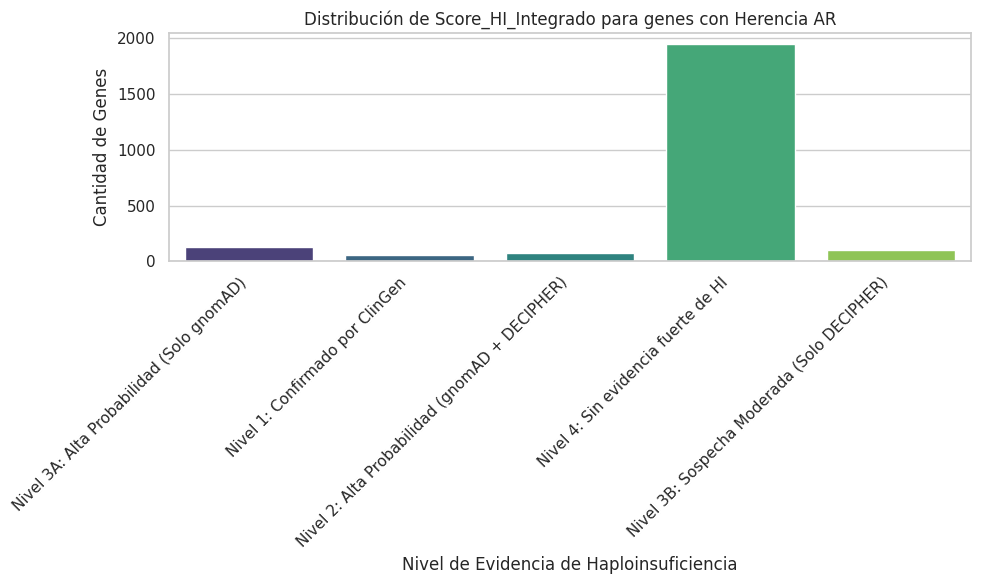

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_ar, x='Score_HI_Integrado', hue='Score_HI_Integrado', palette='viridis', legend=False)
plt.title('Distribución de Score_HI_Integrado para genes con Herencia AR')
plt.xlabel('Nivel de Evidencia de Haploinsuficiencia')
plt.ylabel('Cantidad de Genes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()